#### 1) Importing Necessary Libraries:

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.pipeline import Pipeline

#### 2) Loading Data:

##### Data

An experiment was conducted on 5000 participants to study the effects of age and physical health on hearing loss, specifically the ability to hear high pitched tones. This data displays the result of the study in which participants were evaluated and scored for physical ability and then had to take an audio test (pass/no pass) which evaluated their ability to hear high frequencies. The age of the user was also noted. Is it possible to build a model that would predict someone's liklihood to hear the high frequency sound based solely on their features (age and physical score)?

* Features

    * age - Age of participant in years
    * physical_score - Score achieved during physical exam

* Label/Target

    * test_result - 0 if no pass, 1 if test passed

In [2]:
df = pd.read_csv('hearing_test.csv')

In [3]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [4]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [5]:
df.shape

(5000, 3)

#### 3) Data Exploration and Transformation:

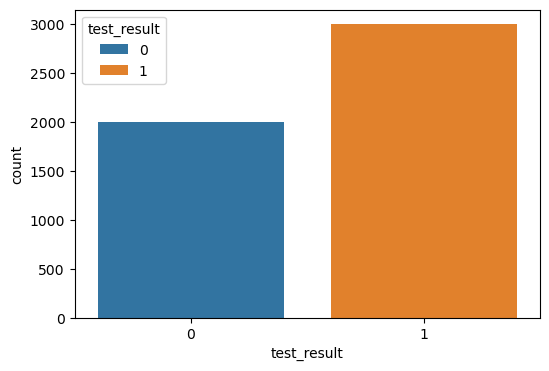

In [7]:
# Count Plot of Test Results:

plt.figure(figsize= (6,4))
sns.countplot(data= df, x= 'test_result', hue= 'test_result')
plt.show()

In [9]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

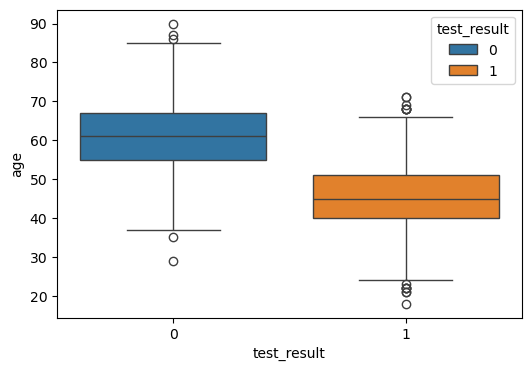

In [19]:
# Relation Between Age and Test Results:

plt.figure(figsize= (6,4))
sns.boxplot(data= df, x= 'test_result', y= 'age', orient= 'v', hue= 'test_result')
plt.show()

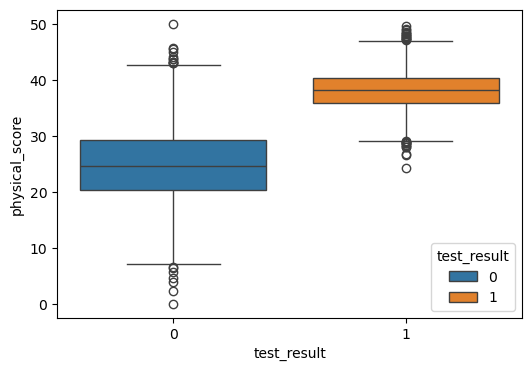

In [20]:
# Relation Between Physical Score and Test Results:

plt.figure(figsize= (6,4))
sns.boxplot(data= df, x= 'test_result', y= 'physical_score', orient= 'v', hue= 'test_result')
plt.show()

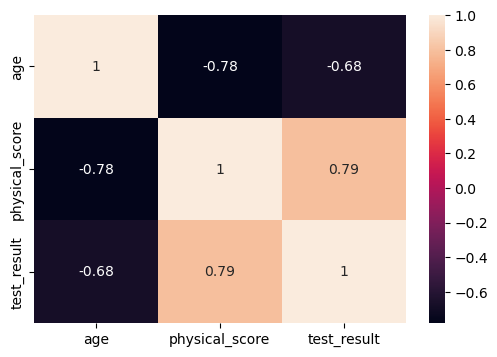

In [22]:
# Feature and Target Correlations:

plt.figure(figsize= (6,4))
sns.heatmap(df.corr(), annot= True)
plt.show()

- Strong Positive Correlation Between "test_result" and "physical_score"

- Strong Negative Correlation Between "test_result" and "age".

<Figure size 600x400 with 0 Axes>

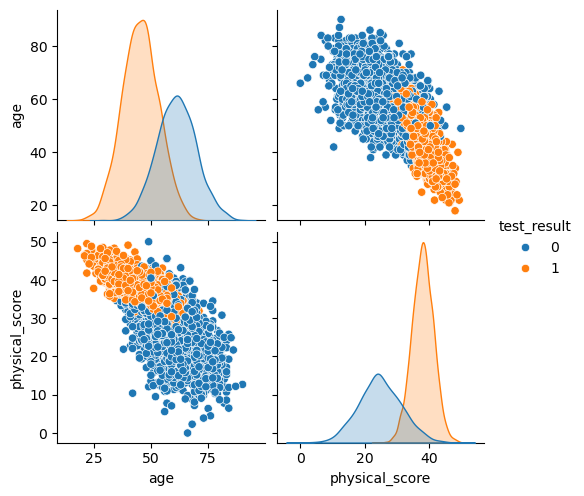

In [26]:
plt.figure(figsize= (6,4))
sns.pairplot(data= df, hue= 'test_result')
plt.show()

- No other transformations needed except Scaling.

In [27]:
# Column Transformer:

cd = ColumnTransformer([
    ('scaler', StandardScaler(), [0,1])
])

#### 4) Train Test Split:

In [28]:
X = df.drop('test_result', axis= 1) # Features
y = df['test_result'] # Target

In [29]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 2)
(1000, 2)
(4000,)
(1000,)


#### Model Building and Evaluation:

In [31]:
model = Pipeline([
    ('preprocessing', cd),
    ('model', LogisticRegression())
])

In [32]:
model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred = model.predict(X_test)

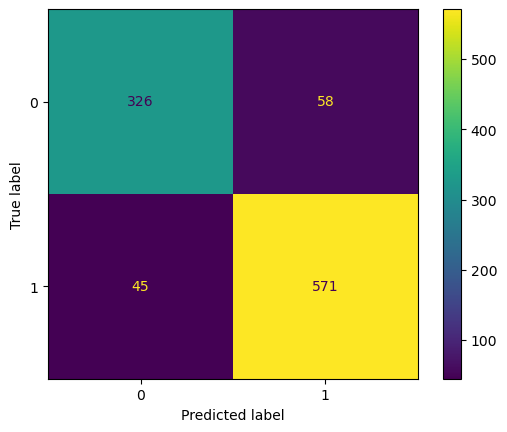

In [45]:
# Model Evaluation:

cm = confusion_matrix(y_test, y_pred, labels= model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels= model.classes_)
disp.plot()
plt.show()

In [39]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       384
           1       0.91      0.93      0.92       616

    accuracy                           0.90      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.90      0.90      0.90      1000



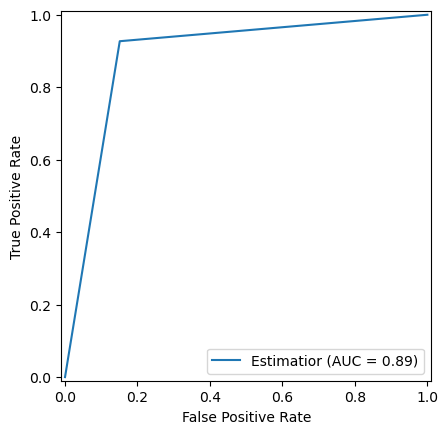

In [47]:
# ROC-AUC Curve:

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  name='Estimatior')
disp.plot()
plt.show()